Lucas Alonso Alonso

# 1. Configuración y Visualización del Entorno (CartPole-v1)
*Este bloque renderiza y guarda un frame del entorno físico sobre el que trabajará el agente.*

In [15]:
import gymnasium as gym
import matplotlib.pyplot as plt

def capturar_entorno_cartpole():
    # Usamos rgb_array para poder guardar la imagen
    env = gym.make('CartPole-v1', render_mode='rgb_array')
    env.reset()

    # Damos un par de pasos aleatorios para que el palo esté un poco inclinado (queda más dinámico)
    for _ in range(5):
        action = env.action_space.sample()
        env.step(action)

    # Capturamos el frame
    frame = env.render()

    # Guardamos la imagen
    plt.figure(figsize=(6, 4))
    plt.imshow(frame)
    plt.axis('off') # Sin ejes, solo la imagen pura
    plt.tight_layout()
    plt.savefig('cartpole_env.png', dpi=300, bbox_inches='tight')
    plt.close()
    env.close()
    print("Imagen 'cartpole_env.png' guardada con éxito.")

capturar_entorno_cartpole()

Imagen 'cartpole_env.png' guardada con éxito.


# 2. Generación del Diagrama de Arquitectura
*Este script automatiza la generación de la arquitectura del sistema híbrido mediante `matplotlib`.*

Diagrama guardado como 'arquitectura_hibrida.png'


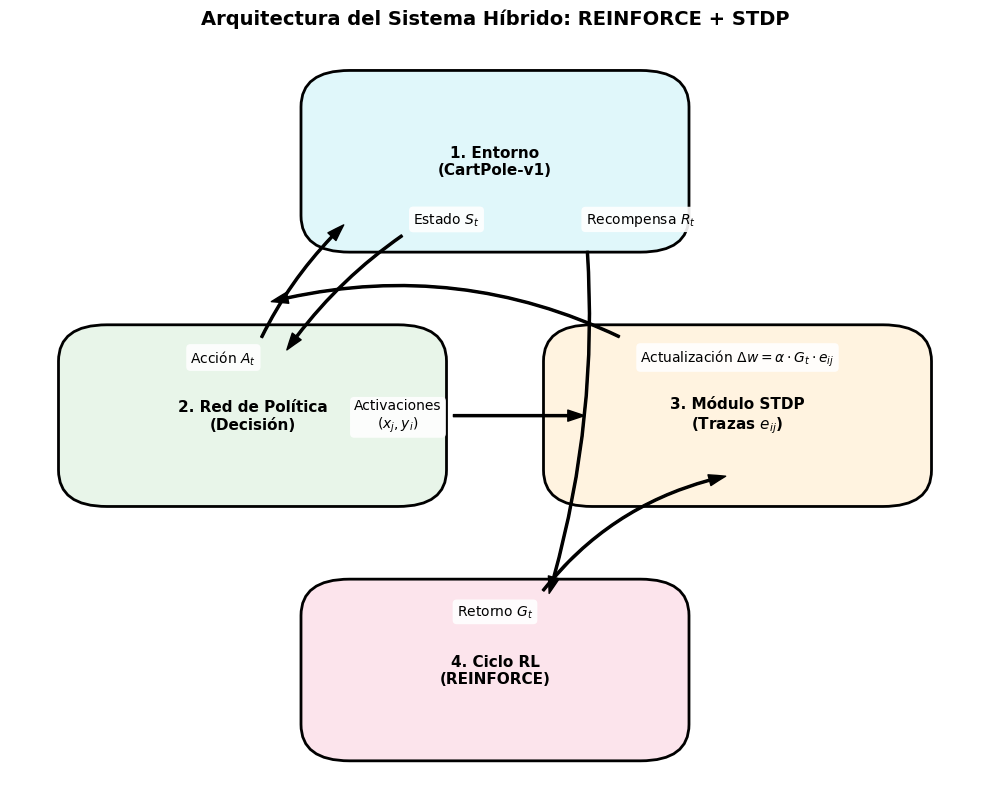

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def draw_architecture_diagram():
    fig, ax = plt.subplots(figsize=(10, 8))

    # Fijamos los límites del lienzo para que no haga un zoom deforme
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    def draw_box(ax, center_x, center_y, width, height, text, facecolor):
        box = patches.FancyBboxPatch(
            (center_x - width/2, center_y - height/2), width, height,
            boxstyle="round,pad=0.05", edgecolor='black', facecolor=facecolor, lw=2
        )
        ax.add_patch(box)
        ax.text(center_x, center_y, text, ha='center', va='center', fontsize=11, fontweight='bold')

    w, h = 0.30, 0.15

    # Creamos cajas con el tamaño suficiente como para apreciarse y no aplastarse
    draw_box(ax, 0.5, 0.85, w, h, "1. Entorno\n(CartPole-v1)", "#e0f7fa")
    draw_box(ax, 0.25, 0.5, w, h, "2. Red de Política\n(Decisión)", "#e8f5e9")
    draw_box(ax, 0.75, 0.5, w, h, "3. Módulo STDP\n(Trazas $e_{ij}$)", "#fff3e0")
    draw_box(ax, 0.5, 0.15, w, h, "4. Ciclo RL\n(REINFORCE)", "#fce4ec")

    def add_arrow(start, end, text, rad=0.1):
        ax.annotate(text, xy=end, xytext=start,
                    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8, connectionstyle=f"arc3,rad={rad}"),
                    fontsize=10, ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9)) # Fondo blanco para leer mejor las flechas

    # Flechas ajustadas para no pisarse
    add_arrow((0.45, 0.77), (0.28, 0.58), "Estado $S_t$", rad=0.1)
    add_arrow((0.22, 0.58), (0.35, 0.77), "Acción $A_t$", rad=-0.1)

    add_arrow((0.65, 0.77), (0.55, 0.23), "Recompensa $R_t$", rad=-0.1)

    add_arrow((0.40, 0.5), (0.60, 0.5), "Activaciones\n($x_j, y_i$)", rad=0.0)

    add_arrow((0.5, 0.23), (0.75, 0.42), "Retorno $G_t$", rad=-0.2)

    # La 'r' (raw string) se pone antes de las comillas para que no de errorres por usar \Delta y así
    add_arrow((0.75, 0.58), (0.25, 0.65), r"Actualización $\Delta w = \alpha \cdot G_t \cdot e_{ij}$", rad=0.2)

    plt.title("Arquitectura del Sistema Híbrido: REINFORCE + STDP", fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig('arquitectura_hibrida.png', dpi=300, bbox_inches='tight')
    print("Diagrama guardado como 'arquitectura_hibrida.png'")
    plt.show()

draw_architecture_diagram()

# 3. Definición del Modelo Línea Base (Adam / Backpropagation)
*Definición de la red clásica estándar y su función de entrenamiento `train_reinforce_baseline`.*

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import gymnasium as gym
import pandas as pd
import os

# --- LÍNEA BASE Clásica (Sin componente bioinspirado) ---
class StandardPolicyNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(StandardPolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        logits = self.fc2(x)
        return torch.softmax(logits, dim=-1)

def train_reinforce_baseline(env_id='CartPole-v1', episodes=500, gamma=0.99, seed=42, lr=1e-3):
    env = gym.make(env_id)
    torch.manual_seed(seed)
    np.random.seed(seed)
    obs, _ = env.reset(seed=seed)

    input_dim = env.observation_space.shape[0]
    output_dim = env.action_space.n
    hidden_dim = 32

    policy = StandardPolicyNetwork(input_dim, hidden_dim, output_dim)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    history_returns = []

    for episode in range(episodes):
        state, _ = env.reset()
        episode_rewards = []
        saved_log_probs = []

        done = False
        truncated = False

        while not (done or truncated):
            state_tensor = torch.FloatTensor(state)
            probs = policy(state_tensor)

            # Usamos distribuciones categóricas para PyTorch estándar
            m = torch.distributions.Categorical(probs)
            action = m.sample()
            saved_log_probs.append(m.log_prob(action))

            next_state, reward, done, truncated, _ = env.step(action.item())
            episode_rewards.append(reward)
            state = next_state

        # Cálculo del retorno y optimización clásica (Backprop)
        G_t = 0
        policy_loss = []
        returns = []
        for r in reversed(episode_rewards):
            G_t = r + gamma * G_t
            returns.insert(0, G_t)

        returns = torch.tensor(returns)
        # Normalizamos los retornos para dar estabilidad a la línea base
        if returns.std() > 0:
            returns = (returns - returns.mean()) / (returns.std() + 1e-9)

        for log_prob, R in zip(saved_log_probs, returns):
            policy_loss.append(-log_prob * R)

        optimizer.zero_grad()
        policy_loss = torch.stack(policy_loss).sum()
        policy_loss.backward()
        optimizer.step()

        history_returns.append(sum(episode_rewards))

    env.close()
    return history_returns

# 4. Definición del Modelo Híbrido (STDP) y Búsqueda de Hiperparámetros
*Definición de la red bioinspirada desconectada de Autograd, su bucle de entrenamiento `train_reinforce_stdp` y la función del Grid Search.*

In [18]:
import torch
import torch.nn as nn
import numpy as np
import gymnasium as gym
import time
import os

# Definimos la Red STDP
class STDPPolicyNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, tau=0.9, alpha=1e-4):
        super(STDPPolicyNetwork, self).__init__()
        self.tau = tau
        self.alpha = alpha
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        nn.init.xavier_uniform_(self.fc1.weight, gain=0.1)
        nn.init.xavier_uniform_(self.fc2.weight, gain=0.1)
        for param in self.parameters():
            param.requires_grad = False
        self.reset_traces()

    def reset_traces(self):
        self.trace_fc1_weight = torch.zeros_like(self.fc1.weight)
        self.trace_fc2_weight = torch.zeros_like(self.fc2.weight)

    def forward(self, x):
        self.input_act = x.clone()
        hidden = torch.relu(self.fc1(x))
        self.hidden_act = hidden.clone()
        logits = self.fc2(hidden)
        logits = logits - torch.max(logits, dim=-1, keepdim=True)[0]
        probs = torch.softmax(logits, dim=-1)
        self.output_act = probs.clone()
        self._update_eligibility_traces()
        return probs

    def _update_eligibility_traces(self):
        delta_trace1 = torch.outer(self.hidden_act, self.input_act)
        self.trace_fc1_weight = self.tau * self.trace_fc1_weight + delta_trace1
        delta_trace2 = torch.outer(self.output_act, self.hidden_act)
        self.trace_fc2_weight = self.tau * self.trace_fc2_weight + delta_trace2

    def update_weights_with_reinforce(self, G_t):
        self.fc1.weight += self.alpha * G_t * self.trace_fc1_weight
        self.fc2.weight += self.alpha * G_t * self.trace_fc2_weight
        self.fc1.weight.data.clamp_(-1.0, 1.0)
        self.fc2.weight.data.clamp_(-1.0, 1.0)


# Función de Entrenamiento
def train_reinforce_stdp(env_id='CartPole-v1', episodes=500, gamma=0.99, seed=42, alpha=1e-4, tau=0.9, hidden_dim=32):

    total_start_time = time.time()
    stdp_total_time = 0.0

    env = gym.make(env_id)
    torch.manual_seed(seed)
    np.random.seed(seed)
    obs, _ = env.reset(seed=seed)

    input_dim = env.observation_space.shape[0]
    output_dim = env.action_space.n

    policy = STDPPolicyNetwork(input_dim, hidden_dim, output_dim, tau=tau, alpha=alpha)

    history_returns = []
    history_traces_magnitude = [] # <<<--- Añadido de nuevo

    for episode in range(episodes):
        state, _ = env.reset()
        episode_rewards = []
        policy.reset_traces()

        done = False
        truncated = False

        while not (done or truncated):
            state_tensor = torch.FloatTensor(state)
            probs = policy(state_tensor)

            p_numpy = probs.detach().numpy()
            action = np.random.choice(output_dim, p=p_numpy)

            next_state, reward, done, truncated, _ = env.step(action)
            episode_rewards.append(reward)
            state = next_state

        G_t = 0
        for r in reversed(episode_rewards):
            G_t = r + gamma * G_t

        # --- BLOQUE DE ACTUALIZACIÓN BIOINSPIRADO ---
        stdp_start = time.time()
        policy.update_weights_with_reinforce(G_t)
        stdp_end = time.time()
        stdp_total_time += (stdp_end - stdp_start)
        # ---------------------------------------------

        total_return = sum(episode_rewards)
        history_returns.append(total_return)

        # Recogemos la traza de nuevo
        mean_trace = torch.mean(torch.abs(policy.trace_fc1_weight)).item()
        history_traces_magnitude.append(mean_trace)

    env.close()

    total_end_time = time.time()
    wall_clock_time = total_end_time - total_start_time
    fraction_stdp = stdp_total_time / wall_clock_time if wall_clock_time > 0 else 0

    return history_returns, history_traces_magnitude, wall_clock_time, fraction_stdp


# Función que ejecuta una búsqueda exhaustiva en los hiperparámetros (GRID SEARCH)
def run_full_grid_search():
    alphas = [5e-5, 1e-4, 5e-4]
    taus = [0.70, 0.85, 0.95]
    hiddens = [16, 32, 64] # Las 3 métricas exigidas (RL, Bio, Estructural)
    seeds = [10, 42, 123, 777, 2024]

    best_score = -float('inf')
    best_config = None

    print("Iniciando Grid Search completo...")

    for h in hiddens:
        print(f"\n--- Evaluando Capa Oculta = {h} ---")
        for alpha in alphas:
            for tau in taus:
                scores_convergencia = []
                tiempos = []
                fracciones = []

                for seed in seeds:
                    retornos, _, w_time, f_stdp = train_reinforce_stdp(alpha=alpha, tau=tau, hidden_dim=h, seed=seed)

                    # Puntuación de convergencia (10% final de 500 = 50 episodios)
                    score_semilla = np.mean(retornos[-50:])
                    scores_convergencia.append(score_semilla)
                    tiempos.append(w_time)
                    fracciones.append(f_stdp)

                mean_score = np.mean(scores_convergencia)
                mean_time = np.mean(tiempos)
                mean_frac = np.mean(fracciones) * 100

                print(f"Alpha: {alpha} | Tau: {tau} -> Score: {mean_score:.2f} | Tiempo: {mean_time:.2f}s | Fracción STDP: {mean_frac:.1f}%")

                if mean_score > best_score:
                    best_score = mean_score
                    best_config = (alpha, tau, h)

    print("\n==================================================")
    print(f"LA MEJOR CONFIGURACIÓN ES: Alpha={best_config[0]}, Tau={best_config[1]}, Hidden={best_config[2]}")
    print(f"Score Máximo de Convergencia: {best_score:.2f}")
    print("==================================================")

# Ejecutar
if __name__ == "__main__":
    run_full_grid_search()

Iniciando Grid Search completo...

--- Evaluando Capa Oculta = 16 ---
Alpha: 5e-05 | Tau: 0.7 -> Score: 11.04 | Tiempo: 1.87s | Fracción STDP: 2.3%
Alpha: 5e-05 | Tau: 0.85 -> Score: 10.16 | Tiempo: 1.80s | Fracción STDP: 2.7%
Alpha: 5e-05 | Tau: 0.95 -> Score: 10.08 | Tiempo: 1.63s | Fracción STDP: 2.7%
Alpha: 0.0001 | Tau: 0.7 -> Score: 10.04 | Tiempo: 1.65s | Fracción STDP: 2.7%
Alpha: 0.0001 | Tau: 0.85 -> Score: 9.99 | Tiempo: 1.42s | Fracción STDP: 2.6%
Alpha: 0.0001 | Tau: 0.95 -> Score: 10.42 | Tiempo: 1.47s | Fracción STDP: 2.8%
Alpha: 0.0005 | Tau: 0.7 -> Score: 10.12 | Tiempo: 1.34s | Fracción STDP: 3.0%
Alpha: 0.0005 | Tau: 0.85 -> Score: 10.02 | Tiempo: 1.44s | Fracción STDP: 3.1%
Alpha: 0.0005 | Tau: 0.95 -> Score: 10.82 | Tiempo: 1.45s | Fracción STDP: 3.1%

--- Evaluando Capa Oculta = 32 ---
Alpha: 5e-05 | Tau: 0.7 -> Score: 12.14 | Tiempo: 1.97s | Fracción STDP: 2.2%
Alpha: 5e-05 | Tau: 0.85 -> Score: 9.99 | Tiempo: 1.78s | Fracción STDP: 2.2%
Alpha: 5e-05 | Tau: 0.95 

# 5. Gestor de Experimentos Final (Logs y Semillas)
*Script automatizado que ejecuta el experimento principal (Línea base vs Híbrido) sobre las 5 semillas con los parámetros ganadores, guardando los resultados en la carpeta `logs/`.*

In [19]:
import os
import pandas as pd

# Gestor de Experimentos (Semillas y Logs)

def run_full_experiment(episodes=500, num_seeds=5): # Dejamos 500 episodios para que cuadre con el LaTeX
    # Creamos el directorio para los registros (Entregable obligatorio)
    os.makedirs('logs', exist_ok=True)
    seeds = [10, 42, 123, 777, 2024] # 5 semillas aleatorias distintas

    print("Iniciando experimentos con los mejores hiperparámetros. Esto puede tardar unos minutos...")

    for seed in seeds[:num_seeds]:
        print(f"\n--- Ejecutando Semilla {seed} ---")

        # Ejecutamos la Línea Base y la guardamos en una variable (solo el retorno)
        print("  Entrenando Línea Base (Adam)...")
        returns_base = train_reinforce_baseline(seed=seed, episodes=episodes)

        # Guardamos CSV de la Línea Base
        df_base = pd.DataFrame({
            'episode': range(episodes),
            'return': returns_base
        })
        df_base.to_csv(f'logs/baseline_seed_{seed}.csv', index=False)

        # Ejecutamos Híbrido Bioinspirado (STDP)
        print("  Entrenando Híbrido (STDP)...")

        returns_stdp, traces_stdp, w_time, f_stdp = train_reinforce_stdp(
            seed=seed,
            episodes=episodes,
            alpha=0.0001,   # El mejor Alpha
            tau=0.7,        # El mejor Tau
            hidden_dim=32   # La mejor Capa Oculta
        )

        print(f"  -> Semilla {seed} STDP completada en {w_time:.2f}s (Fracción bioinspirada: {f_stdp*100:.1f}%)")

        # Guardamos CSV del Híbrido
        df_stdp = pd.DataFrame({
            'episode': range(episodes),
            'return': returns_stdp,
            'mean_trace_magnitude': traces_stdp
        })
        df_stdp.to_csv(f'logs/hybrid_stdp_seed_{seed}.csv', index=False)

    print("\nLos experimentos fueron realizados con éxito. Todos los archivos .csv han sido guardados en la carpeta 'logs/'.")

# Ejecutamos el experimento final
if __name__ == "__main__":
    run_full_experiment(episodes=500, num_seeds=5)

Iniciando experimentos con los mejores hiperparámetros. Esto puede tardar unos minutos...

--- Ejecutando Semilla 10 ---
  Entrenando Línea Base (Adam)...
  Entrenando Híbrido (STDP)...
  -> Semilla 10 STDP completada en 5.40s (Fracción bioinspirada: 1.3%)

--- Ejecutando Semilla 42 ---
  Entrenando Línea Base (Adam)...
  Entrenando Híbrido (STDP)...
  -> Semilla 42 STDP completada en 1.43s (Fracción bioinspirada: 2.6%)

--- Ejecutando Semilla 123 ---
  Entrenando Línea Base (Adam)...
  Entrenando Híbrido (STDP)...
  -> Semilla 123 STDP completada en 1.69s (Fracción bioinspirada: 2.9%)

--- Ejecutando Semilla 777 ---
  Entrenando Línea Base (Adam)...
  Entrenando Híbrido (STDP)...
  -> Semilla 777 STDP completada en 1.45s (Fracción bioinspirada: 2.5%)

--- Ejecutando Semilla 2024 ---
  Entrenando Línea Base (Adam)...
  Entrenando Híbrido (STDP)...
  -> Semilla 2024 STDP completada en 2.31s (Fracción bioinspirada: 2.7%)

Los experimentos fueron realizados con éxito. Todos los archivos .

# 6. Gráfica de Sensibilidad de Hiperparámetros (Grid Search)
*Generación de la gráfica comparativa de variaciones de Alpha, Tau y Neuronas Ocultas.*

Gráfica hyperparameter_sweeps.png generada con éxito.


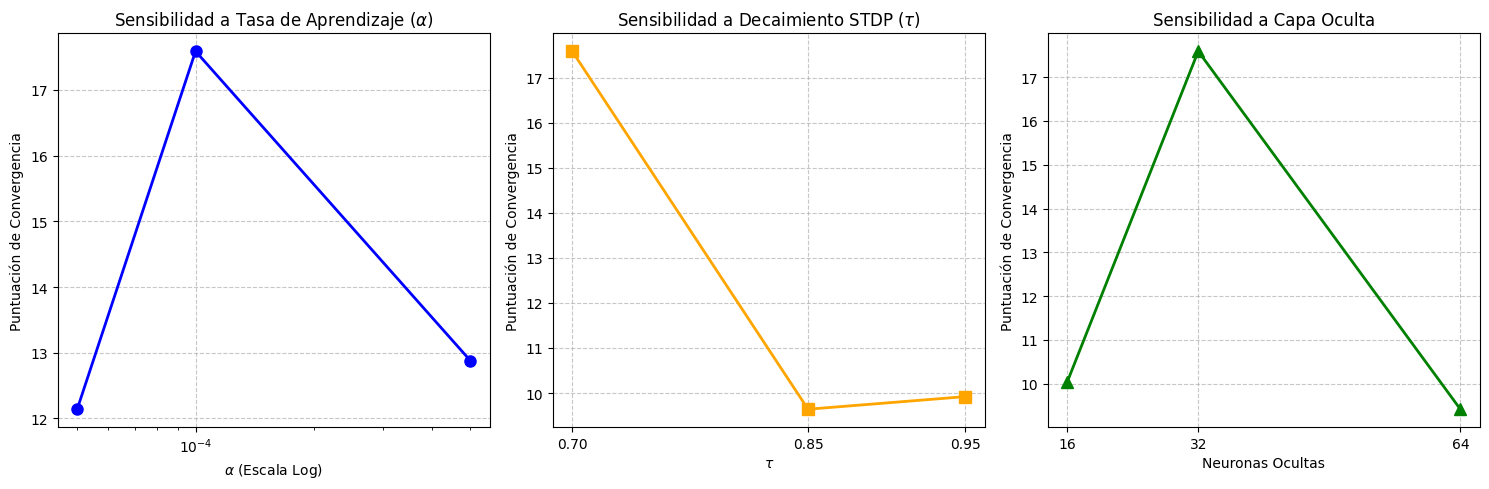

In [20]:
import matplotlib.pyplot as plt

def plot_grid_search_marginals():
    # Óptimo: Alpha=1e-4, Tau=0.7, Hidden=32

    # Variamos solo el Alpha (dejamos fijos: Tau=0.7, Hidden=32)
    alphas = [5e-5, 1e-4, 5e-4]
    scores_alpha = [12.14, 17.59, 12.88]

    # Variamos solo el Tau (dejamos fijos: Alpha=1e-4, Hidden=32)
    taus = [0.70, 0.85, 0.95]
    scores_tau = [17.59, 9.64, 9.92]

    # Variamos solo el Hidden (dejamos fijos: Alpha=1e-4, Tau=0.7)
    hiddens = [16, 32, 64]
    scores_hidden = [10.04, 17.59, 9.42]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot Alpha
    axes[0].plot(alphas, scores_alpha, marker='o', markersize=8, color='blue', linewidth=2)
    axes[0].set_title('Sensibilidad a Tasa de Aprendizaje ($\\alpha$)')
    axes[0].set_xlabel('$\\alpha$ (Escala Log)')
    axes[0].set_xscale('log')
    axes[0].set_ylabel('Puntuación de Convergencia')
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Plot Tau
    axes[1].plot(taus, scores_tau, marker='s', markersize=8, color='orange', linewidth=2)
    axes[1].set_title('Sensibilidad a Decaimiento STDP ($\\tau$)')
    axes[1].set_xlabel('$\\tau$')
    axes[1].set_xticks(taus)
    axes[1].set_ylabel('Puntuación de Convergencia')
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # Plot Hidden Dim
    axes[2].plot(hiddens, scores_hidden, marker='^', markersize=8, color='green', linewidth=2)
    axes[2].set_title('Sensibilidad a Capa Oculta')
    axes[2].set_xlabel('Neuronas Ocultas')
    axes[2].set_xticks(hiddens)
    axes[2].set_ylabel('Puntuación de Convergencia')
    axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig('hyperparameter_sweeps.png', dpi=300)
    print("Gráfica hyperparameter_sweeps.png generada con éxito.")

plot_grid_search_marginals()

# 7. Resultados Finales: Análisis Estadístico y Curvas de Aprendizaje
*Procesamiento final de los CSVs generados para extraer el Valor-P, el Delta, y generar las gráficas de curvas de aprendizaje y dinámica interna de las trazas (las cuales irán a parar al directorio `figures/`).*

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def load_data(num_seeds=5):
    """Carga los datos de los CSVs generados previamente"""
    seeds = [10, 42, 123, 777, 2024][:num_seeds]

    baseline_returns = []
    hybrid_returns = []
    hybrid_traces = []

    for seed in seeds:
        df_base = pd.read_csv(f'logs/baseline_seed_{seed}.csv')
        df_hybrid = pd.read_csv(f'logs/hybrid_stdp_seed_{seed}.csv')

        baseline_returns.append(df_base['return'].values)
        hybrid_returns.append(df_hybrid['return'].values)
        hybrid_traces.append(df_hybrid['mean_trace_magnitude'].values)

    return np.array(baseline_returns), np.array(hybrid_returns), np.array(hybrid_traces)

def smooth(data, window=20):
    """Aplica una media móvil para suavizar las curvas."""
    return np.array([np.convolve(row, np.ones(window)/window, mode='valid') for row in data])

def main():
    # Creamos directorio para las figuras
    os.makedirs('figures', exist_ok=True)

    # Cargamos los datos
    print("Cargando datos de los registros...")
    try:
        base_ret, hybrid_ret, hybrid_traces = load_data()
    except FileNotFoundError:
        print("ERROR: No se encuentran los CSVs. Ejecuta primero run_full_experiment().")
        return

    # Calculamos Estadísticos Oficiales (Parte I del Boletín)
    #  Y puntuación de convergencia (media del 10% final)
    k_final = int(base_ret.shape[1] * 0.1)
    base_conv = np.mean(base_ret[:, -k_final:], axis=1) # Medias por semilla
    hybrid_conv = np.mean(hybrid_ret[:, -k_final:], axis=1)

    mean_base = np.mean(base_conv)
    mean_hybrid = np.mean(hybrid_conv)

    # Mejora Relativa Delta
    delta = (mean_hybrid - mean_base) / abs(mean_base)

    # Prueba t de Welch
    t_stat, p_value = stats.ttest_ind(hybrid_conv, base_conv, equal_var=False)

    print("\n====================================================================")
    print(" RESULTADOS ESTADÍSTICOS (TABLA II del LaTeX)")
    print("====================================================================")
    print(f"Convergencia Línea Base (Adam):  {mean_base:.2f} ± {np.std(base_conv):.2f}")
    print(f"Convergencia Híbrido (STDP):     {mean_hybrid:.2f} ± {np.std(hybrid_conv):.2f}")
    print(f"Mejora Relativa (Delta):         {delta * 100:.2f}%")
    print(f"Valor-p (Prueba Welch):          {p_value:.5f}")
    print("--------------------------------------------------------------------")
    if p_value < 0.05:
        print("-> La diferencia es ESTADÍSTICAMENTE SIGNIFICATIVA (p < 0.05)")
    else:
        print("-> La diferencia NO es estadísticamente significativa (p >= 0.05)")
    print("====================================================================\n")

    # Generamos las Figuras
    print("Generando y guardando figuras...")

    # Figura 1: Curvas de Aprendizaje (con banda de varianza)
    plt.figure(figsize=(10, 6))

    # Suavizamos y calculamos medias y desviaciones estándar
    base_smooth = smooth(base_ret)
    hyb_smooth = smooth(hybrid_ret)

    x_axis = range(19, base_ret.shape[1]) # Eje ajustado por la ventana de suavizado

    # Plot Baseline
    plt.plot(x_axis, np.mean(base_smooth, axis=0), color='gray', label='Línea Base (Adam)')
    plt.fill_between(x_axis,
                     np.mean(base_smooth, axis=0) - np.std(base_smooth, axis=0),
                     np.mean(base_smooth, axis=0) + np.std(base_smooth, axis=0),
                     color='gray', alpha=0.2)

    # Plot Hybrid
    plt.plot(x_axis, np.mean(hyb_smooth, axis=0), color='blue', label='Híbrido (STDP)')
    plt.fill_between(x_axis,
                     np.mean(hyb_smooth, axis=0) - np.std(hyb_smooth, axis=0),
                     np.mean(hyb_smooth, axis=0) + np.std(hyb_smooth, axis=0),
                     color='blue', alpha=0.2)

    plt.title('Curvas de Aprendizaje: STDP vs Adam')
    plt.xlabel('Episodios')
    plt.ylabel('Retorno de Episodio (Media Móvil)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig('figures/learning_curves.png', dpi=300)
    plt.close()

    # Figura 2: Dinámica Interna (Diagnóstico Obligatorio)
    plt.figure(figsize=(10, 4))
    traces_mean = np.mean(hybrid_traces, axis=0)
    traces_std = np.std(hybrid_traces, axis=0)

    plt.plot(traces_mean, color='darkorange', label='Magnitud Media de Trazas e_ij')
    plt.fill_between(range(len(traces_mean)),
                     traces_mean - traces_std,
                     traces_mean + traces_std,
                     color='darkorange', alpha=0.2)

    plt.title('Dinámica Interna: Evolución de las Trazas STDP')
    plt.xlabel('Episodios')
    plt.ylabel('Magnitud Absoluta')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.savefig('figures/internal_dynamics.png', dpi=300)
    plt.close()

    print("Figuras guardadas correctamente en la carpeta 'figures/'.")

if __name__ == '__main__':
    main()

Cargando datos de los registros...

 RESULTADOS ESTADÍSTICOS (TABLA II del LaTeX)
Convergencia Línea Base (Adam):  142.59 ± 55.70
Convergencia Híbrido (STDP):     17.59 ± 16.00
Mejora Relativa (Delta):         -87.66%
Valor-p (Prueba Welch):          0.00895
--------------------------------------------------------------------
-> La diferencia es ESTADÍSTICAMENTE SIGNIFICATIVA (p < 0.05)

Generando y guardando figuras...
Figuras guardadas correctamente en la carpeta 'figures/'.
